# EDA inicial - Cancelación de reservas

Este notebook analiza nulos, distribución de clases y variables clave para justificar el enfoque de modelado.

## Justificación de métricas

Se usa **AUC-ROC** como métrica principal porque el problema puede estar desbalanceado y AUC-ROC evalúa la capacidad discriminativa del modelo para todos los umbrales.

Además se reportan **accuracy, precision, recall y F1-score** para analizar costes de falsos positivos y falsos negativos.

## 1. Carga e inspección

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/raw/dataset_practica_final.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Mostrar las dimensiones del DataFrame
df.shape

# Tipos de datos de cada columna
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [4]:
# Información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## 2. Variable objetivo

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


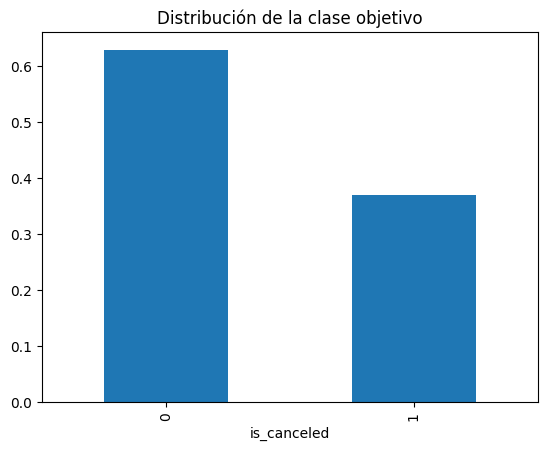

In [6]:
# Selección de la variable objetivo
target = df['is_canceled']

# Distribución de la clase objetivo 
print(target.value_counts())

# Distribución de la clase objetivo en porcentaje
print(target.value_counts(normalize=True) * 100)

# Visualización en porcentaje de la distribución de la clase objetivo
target.value_counts(normalize=True).plot(kind='bar', title='Distribución de la clase objetivo')
plt.show()

## 3. Valores nulos y duplicados

In [7]:
# Cuantos nulos hay en cada columna
print(f"Nulos por columna:\n{df.isnull().sum()}")


# Separador 
print("=" * 50)

# Filas duplicadas
print(f"Filas duplicadas: {df.duplicated().sum()}")

Nulos por columna:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              163

## 3.1 Tratamiento de valores nulos

In [10]:
df_clean = df.copy()

# children: 4 nulos: imputar con 0
df_clean['children'] = df_clean['children'].fillna(0)

# country: 488 nulos: imputar con 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')

# agent: 16.340 nulos: el nulo significa "sin agente" (reserva directa)
# Se convierte en variable binaria más informativa que el ID numérico
df_clean['has_agent'] = df_clean['agent'].notnull().astype(int)
df_clean = df_clean.drop(columns=['agent'])

# company: 94.3% nulos: eliminar directamente
df_clean = df_clean.drop(columns=['company'])

## 4. Estadísticas descriptivas

In [12]:
# Resumen estadístico de las columnas numéricas
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [13]:
# Resumen estadístico de las columnas categóricas
df.describe(include='object').transpose()

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


## 5. Distribuciones de variables numéricas

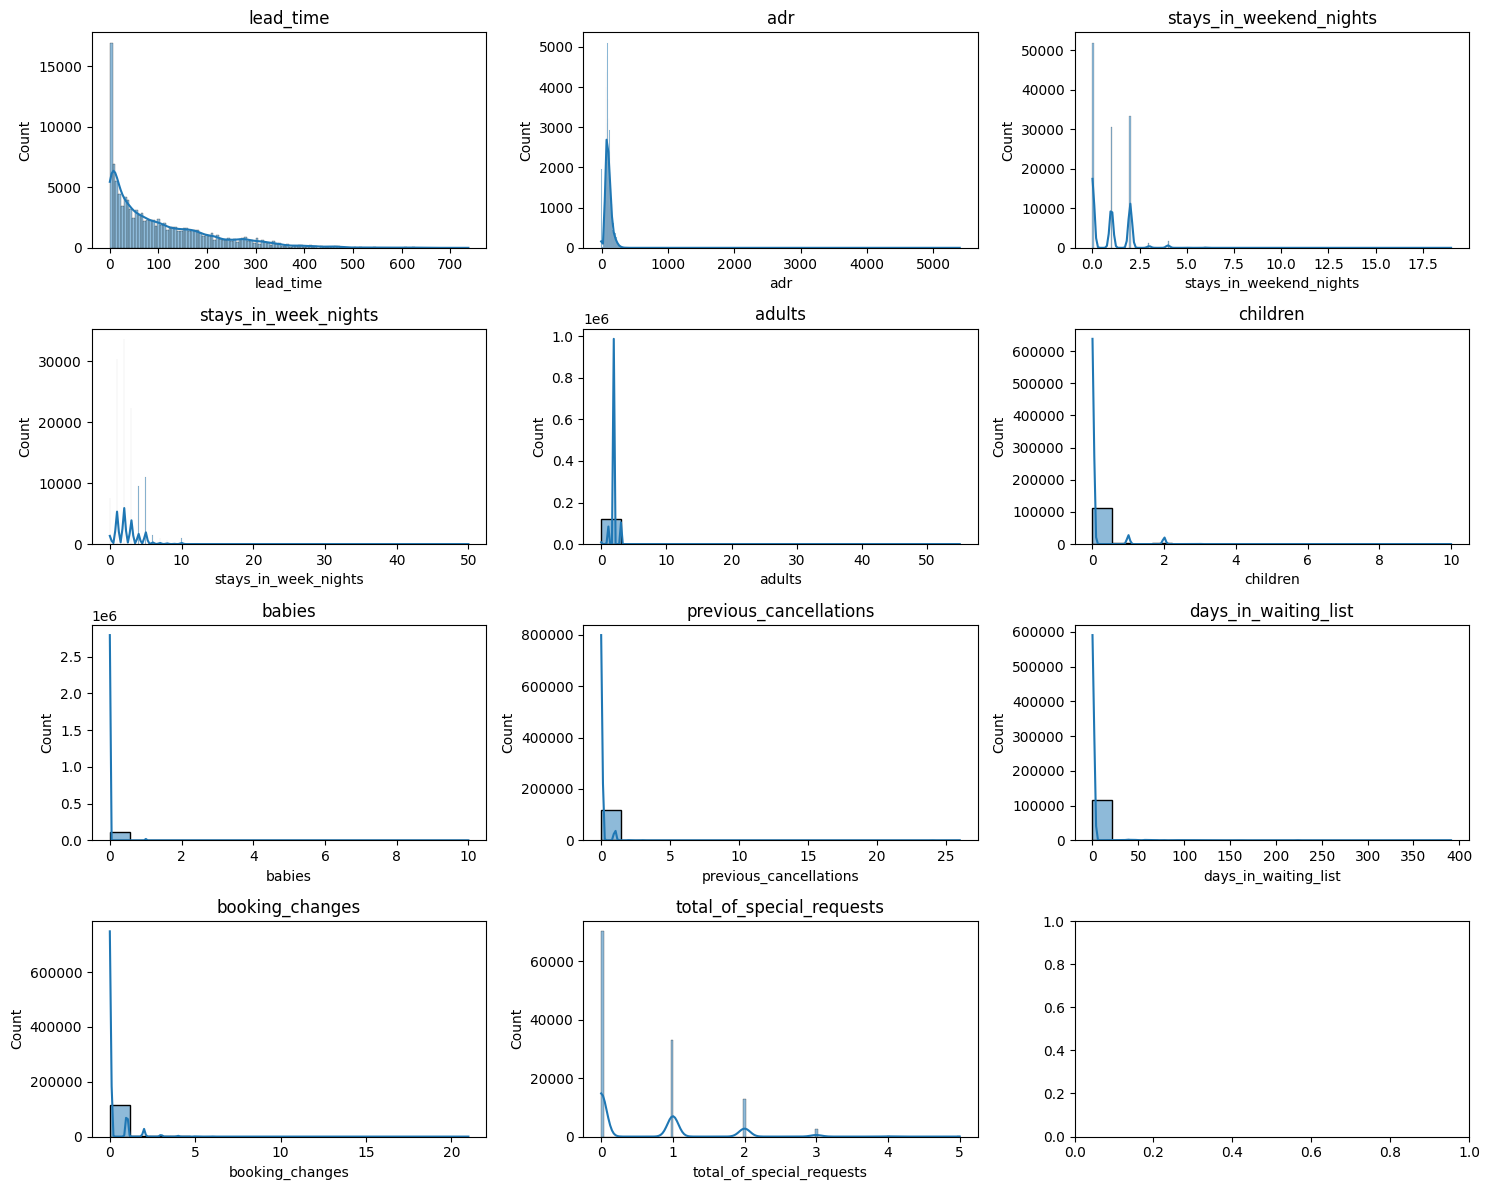

In [14]:
# Visualización de la distribución de las variables numéricas
cols_to_plot = [
    'lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'days_in_waiting_list', 'booking_changes', 'total_of_special_requests'
]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


## 6. Variables categóricas

In [15]:
# Recuento de valores únicos en columnas categóricas
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"Columna: {col}")
    print(df[col].value_counts())
    print("=" * 40)

Columna: hotel
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
Columna: arrival_date_month
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64
Columna: meal
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64
Columna: country
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
DJI        1
BWA        1
HND        1
VGB        1
NAM        1
Name: count, Length: 177, dtype: int64
Columna: market_segment
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64
Columna: dis

## 7. Correlaciones

In [ ]:
# Matriz de correlación para variables numéricas
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()
